In [57]:
from scipy.integrate import solve_ivp,solve_bvp
import matplotlib.pyplot as plt
import numpy as np
# question 2

L = 0.001
D = 1.2e-9
k = 0.001
CA0 = 0.2
uL = 0

def dcdx(x, C):
    # C = [CA, u]
    return [C[1], (k/D)*C[0]]

guess1 = -CA0/L # assume SLD
guess2 = guess1*2

sol1 = solve_ivp(dcdx, [0,L], [CA0, guess1], t_eval=np.linspace(0, L, 100))
uLg1 = sol1.y[-1][-1]

sol2 = solve_ivp(dcdx, [0,L], [CA0, guess2], t_eval=np.linspace(0, L, 100))
uLg2 = sol2.y[-1][-1]

u0 = guess1 - (uLg1 - uL) * (guess2-guess1)/(uLg2-uLg1)

sol = solve_ivp(dcdx,[0,L],[CA0,u0],t_eval=np.linspace(0,L,100)) 

In [48]:
def mybc(C0,CL):
	# inputs C0 = [CA(0)  u(0)]'
	#        CL = [CA(L)  u(L)]'
	resid = [C0[0]-CA0,CL[1]-uL]
	return resid

In [54]:
# solve bvp method
x_vals = np.linspace(0, L, 100)
solv_bv = solve_bvp(dcdx, mybc, x_vals, np.zeros((2, x_vals.size)))

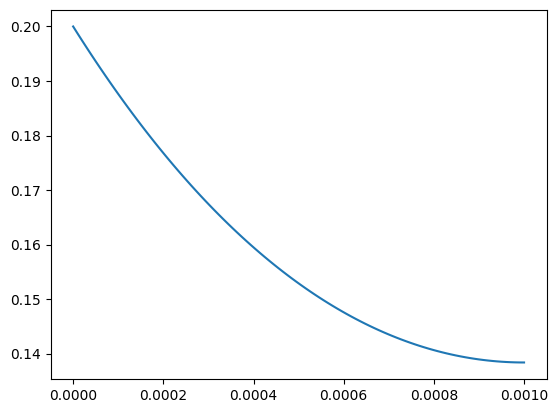

In [55]:
plt.plot(sol.t, sol.y[0])

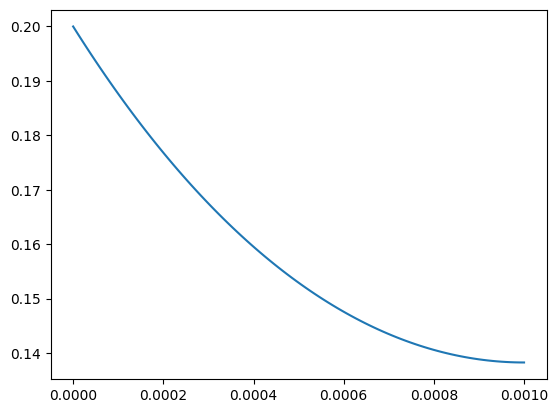

In [56]:
plt.plot(solv_bv.x, solv_bv.y[0])

In [ ]:
# Different Method for IVP thingy

from scipy.integrate import solve_ivp,solve_bvp
import matplotlib.pyplot as plt
import numpy as np
# question 2

L = 0.001
D = 1.2e-9
k = 0.001
CA0 = 0.2
uL = 0

def dcdx(x, C):
    # C = [CA, u]
    return [C[1], (k/D)*C[0]]

guess1 = -CA0/L # assume SLD
guess2 = guess1*2

sol1 = solve_ivp(dcdx, [0,L], [CA0, guess1], t_eval=np.linspace(0, L, 100))
uLg1 = sol1.y[-1][-1]

sol2 = solve_ivp(dcdx, [0,L], [CA0, guess2], t_eval=np.linspace(0, L, 100))
uLg2 = sol2.y[-1][-1]

u0 = guess1 - (uLg1 - uL) * (guess2-guess1)/(uLg2-uLg1)

sol = solve_ivp(dcdx,[0,L],[CA0,u0],t_eval=np.linspace(0,L,100)) 